In [1]:
import rasterio
import rasterio.mask
import r5py as r5
import h3
import geopandas as gpd
from shapely.geometry import Polygon, box
from scipy.spatial.distance import jensenshannon
from scipy.stats import entropy
from pyrosm import OSM
import numpy as np
from pyrosm.data import sources
from pyrosm import get_data
import matplotlib.pyplot as plt
import pandas as pd
from datetime import timedelta
from reusable import *

#### **Paths and Data**

In [2]:
osm_path = r'cities\bratislava\bratislavsky.pbf'
gtfs_path = 'cities\\bratislava\\tld-3363-202602280130.zip'
pop_path = r'cities\bratislava\svk_pop_2026_CN_100m_R2025A_v1.tif'
bound_path = r"cities\bratislava\bratislava_boundary.geojson"

In [3]:
tn = r5.TransportNetwork(osm_path)

#### **Boundaries + grid**

In [4]:
osm = OSM(osm_path)
boundaries = osm.get_boundaries()
#boundaries.sort_values(by="admin_level", ascending=False).head(10)

Using local GeoJSON/Shapefile boundary

In [5]:
city_proj = gpd.read_file(bound_path)
city_proj = city_proj.to_crs(city_proj.estimate_utm_crs())
city_proj = city_proj.dissolve()

<Axes: >

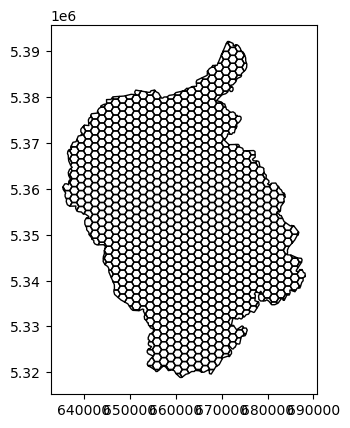

In [6]:
grid = create_hex_grid(city_proj, 1000)
grid.plot(edgecolor='black', facecolor='none')

#### **Populating the grid**

In [7]:
def assign_population_to_grid(pop_raster_path, grid, plot=True):

    # safely handle mixed geometry types without index conflicts
    grid_out = grid.copy()
    grid_out = grid_out.explode(index_parts=False)       # explode MultiPolygons → Polygons
    grid_out["geometry"] = grid_out["geometry"].buffer(0) # fix invalid geoms
    grid_out = grid_out[~grid_out.geometry.is_empty]      # drop empty geoms
    grid_out = grid_out.reset_index(drop=True)            # reset AFTER all geometry ops
    grid_out["id"] = grid_out.index.astype(str)

    with rasterio.open(pop_raster_path) as src:
        raster_crs = src.crs
        grid_raster_crs = grid_out.to_crs(raster_crs)

        # explode + clean the reprojected copy too for rasterio masking
        grid_raster_crs = grid_raster_crs.explode(index_parts=False).reset_index(drop=True)
        grid_raster_crs["geometry"] = grid_raster_crs["geometry"].buffer(0)
        grid_raster_crs = grid_raster_crs[~grid_raster_crs.geometry.is_empty]

        from shapely.geometry import mapping
        geoms = [mapping(geom) for geom in grid_raster_crs.geometry]

        try:
            out_image, out_transform = rasterio.mask.mask(src, geoms, crop=True)
        except Exception as e:
            raise ValueError(f"Raster masking failed: {e}")

        nodata = src.nodata
        res_x = abs(out_transform.a)
        res_y = abs(out_transform.e)

    arr = out_image[0].astype(float) # apply mask 
    if nodata is not None:
        arr[arr == nodata] = np.nan

    rows, cols = np.where((~np.isnan(arr)) & (arr > 0))

    if len(rows) == 0: # data validity check
        print("Warning: No valid population values found in raster within grid extent.")
        grid_out["population"] = 0.0
        return grid_out

    xs, ys = rasterio.transform.xy(out_transform, rows, cols)
    pop_values = arr[rows, cols]

    # build rectangular cell polygons around each raster cell centre
    cell_polygons = [
        box(x - res_x / 2, y - res_y / 2, x + res_x / 2, y + res_y / 2)
        for x, y in zip(xs, ys)
    ]
    raster_cells = gpd.GeoDataFrame(
        {"cell_pop": pop_values},
        geometry=cell_polygons,
        crs=raster_crs
    )

    # --- 3) Reproject raster cells to grid CRS ---
    raster_cells = raster_cells.to_crs(grid_out.crs)
    raster_cells["cell_area"] = raster_cells.geometry.area

    # --- 4) Intersect raster cells with hex polygons ---
    intersection = gpd.overlay(
        raster_cells[["cell_pop", "cell_area", "geometry"]],
        grid_out[["id", "geometry"]],
        how="intersection"
    )

    if intersection.empty:
        print("Warning: No intersection between raster cells and grid.")
        grid_out["population"] = 0.0
        return grid_out

    # --- 5) Proportional allocation ---
    intersection["int_area"] = intersection.geometry.area
    intersection["pop_share"] = intersection["int_area"] / intersection["cell_area"]
    intersection["pop_allocated"] = intersection["cell_pop"] * intersection["pop_share"]

    hex_pop = (
        intersection.groupby("id")["pop_allocated"]
        .sum()
        .reset_index()
        .rename(columns={"pop_allocated": "population"})
    )

    # --- 6) Merge back onto original grid ---
    grid_out = grid_out.merge(hex_pop, on="id", how="left")
    grid_out["population"] = grid_out["population"].fillna(0.0)

    # --- 7) Validate totals ---
    raster_total = float(pop_values.sum())
    hex_total = float(grid_out["population"].sum())
    print(f"Raster total population:  {raster_total:,.0f}")
    print(f"Hex grid total population: {hex_total:,.0f}")
    print(f"Coverage: {hex_total / raster_total * 100:.1f}%")

    # --- 8) Optional plot ---
    if plot:
        fig, ax = plt.subplots(1, 1, figsize=(14, 12))
        grid_out.plot(
            column="population",
            cmap="YlOrRd",
            scheme="Quantiles",
            k=9,
            legend=True,
            linewidth=0.02,
            edgecolor="black",
            legend_kwds={
                "loc": "lower right",
                "title": "Population\n(9 quantiles)",
                "fmt": "{:.0f}"
            },
            ax=ax
        )
        ax.set_title("Population by Hexagon (areal disaggregation)", fontsize=18)
        ax.set_axis_off()
        plt.tight_layout()
        plt.show()

    return grid_out

Raster total population:  732,913
Hex grid total population: 732,866
Coverage: 100.0%


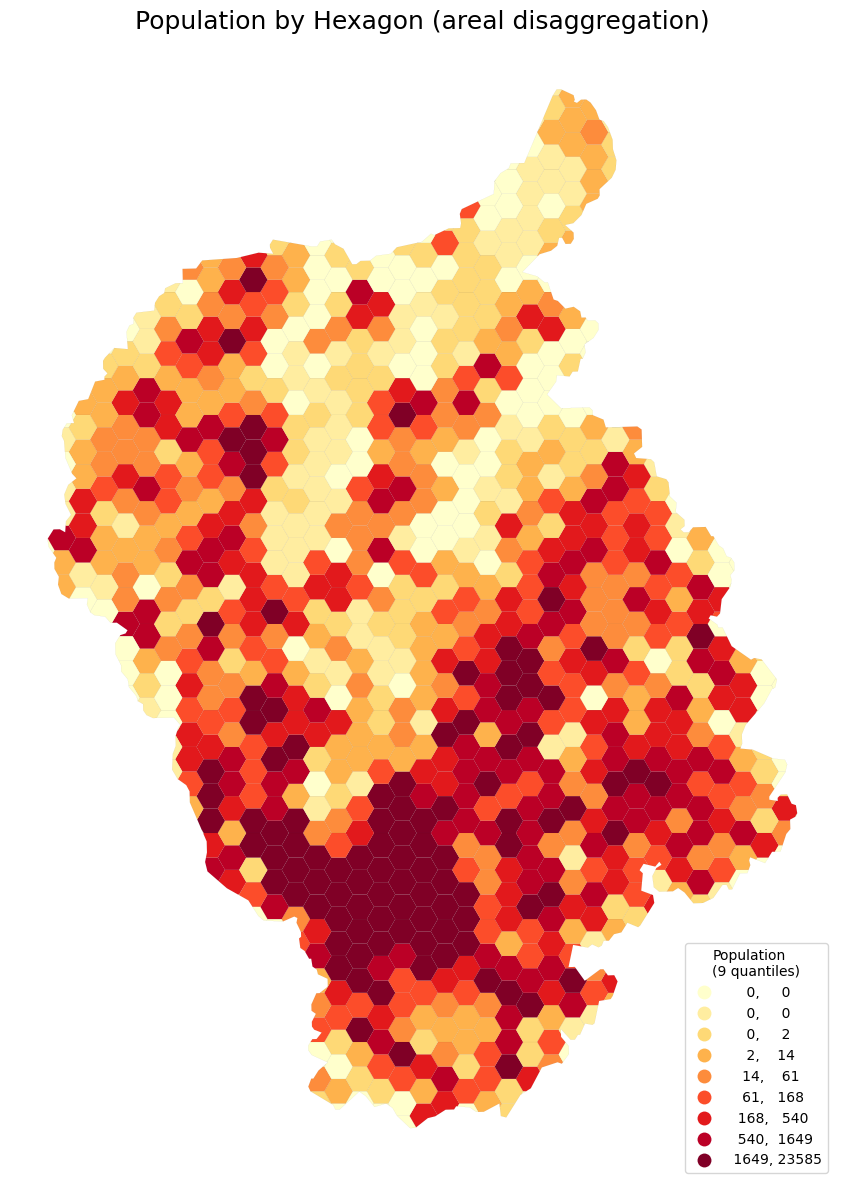

In [8]:
grid_pop = assign_population_to_grid(pop_path, grid, plot=True)

In [9]:
result_geo = build_city_geojson(
    grid=grid,
    grid_pop=grid_pop,
    osm=osm,
    tn=tn,
    output_path="data/bratislava_scores.geojson",
    transport_modes=[r5.TransportMode.TRANSIT, r5.TransportMode.WALK],
    max_time=25,
    beta=0.0277,
    gravity_normalisation=100,
)

d:\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\r5py\r5\regional_task.py:205: RuntimeWarning: The currently loaded GTFS data sets do not define any services on 2026-05-05.
  warnings.warn(


City-wide baseline distribution:
  count_community: 0.089
  count_education: 0.116
  count_essential_services: 0.141
  count_food_and_drink: 0.444
  count_healthcare: 0.141
  count_shelter: 0.069


#### **Origins**

In [9]:
origins = create_origins(grid, grid_pop)
origins.head(5)

,geometry,id,population
0,POINT (17.09095 48.01827),0,0.000000
1,POINT (17.11208 48.02418),1,0.000000
2,POINT (17.07582 48.02517),2,0.287544
3,POINT (17.0914 48.02761),3,12.499492
4,POINT (17.11182 48.03503),4,1.277604


#### **Destinations (POIs)**

In [10]:
destinations = create_POIs(osm, summary=True)

Total amenities: 10288

By type:
amenity class
food_and_drink        2991
healthcare             941
essential_services     928
education              810
parcel_locker          657
community              636
shelter                482
toilets                285
charging_station       210
fountain               195


#### **Finally testing :DD**

In [11]:
categories = ['food_and_drink','shelter','essential_services','education','healthcare','community']

In [12]:
essentials = destinations[destinations['amenity class'].isin(categories)]

In [13]:
travel_time_matrix = r5.TravelTimeMatrix(
    tn,
    origins=origins,
    destinations=essentials,
    transport_modes=[r5.TransportMode.TRANSIT, r5.TransportMode.WALK],
    max_time=timedelta(minutes=35) #CUTOFF
)

d:\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\r5py\r5\regional_task.py:205: RuntimeWarning: The currently loaded GTFS data sets do not define any services on 2026-04-14.
  warnings.warn(


In [14]:
min_tt_wide = min_travel_time(travel_time_matrix, essentials)
min_tt_wide.head(10)

,from_id,min_tt_community,min_tt_education,min_tt_essential_services,min_tt_food_and_drink,min_tt_healthcare,min_tt_shelter,avg_tt,n_unreachable_categories
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
1,1,24.0,NaN,NaN,NaN,NaN,NaN,24.000000,5
2,10,7.0,4.0,2.0,4.0,13.0,NaN,6.000000,1
3,100,13.0,11.0,20.0,12.0,11.0,25.0,15.333333,0
4,101,32.0,24.0,NaN,1.0,27.0,4.0,17.600000,1
5,102,15.0,34.0,NaN,10.0,NaN,6.0,16.250000,2
6,103,NaN,13.0,8.0,9.0,9.0,32.0,14.200000,1
7,104,27.0,14.0,6.0,6.0,9.0,22.0,14.000000,0
8,105,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
9,106,NaN,NaN,31.0,4.0,29.0,26.0,22.500000,2


#### **Exponential Decay**

In [15]:
# examples
for cutoff in [25, 30, 35, 40]:
    b = suggested_beta(cutoff)
    print(f"cutoff={cutoff}min, 50% weight retained → β = {b:.4f}")


cutoff=25min, 50% weight retained → β = 0.0277
cutoff=30min, 50% weight retained → β = 0.0231
cutoff=35min, 50% weight retained → β = 0.0198
cutoff=40min, 50% weight retained → β = 0.0173


cutoff=25min, 50% weight retained → β = 0.0644


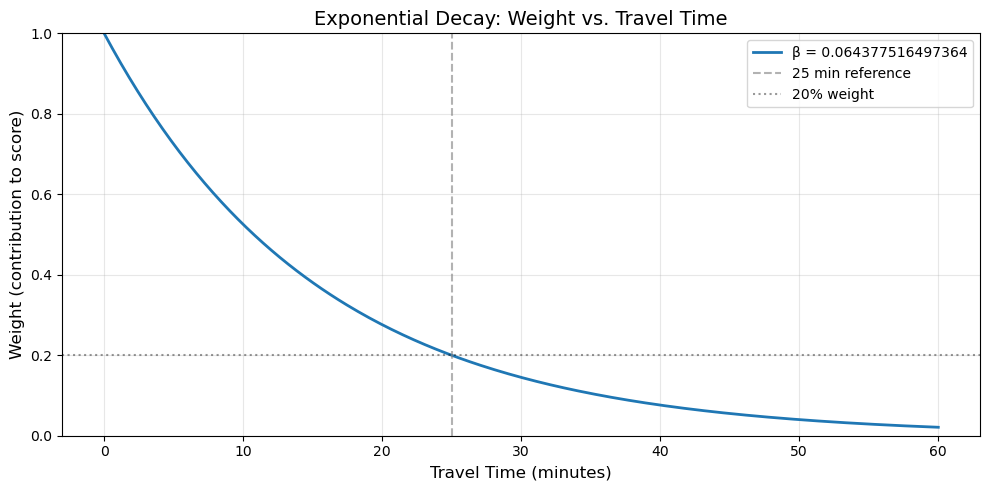

In [16]:
def plot_decay_curves(betas, max_time=60, cutoff_line=30, target_weight=0.5):
    t = np.linspace(0, max_time, 300)

    fig, ax = plt.subplots(figsize=(10, 5))
    for beta in betas:
        ax.plot(t, np.exp(-beta * t), label=f"β = {beta}", linewidth=2)

    ax.axvline(cutoff_line, color="grey", linestyle="--", alpha=0.6,
               label=f"{cutoff_line} min reference")
    ax.axhline(target_weight, color="black", linestyle=":", alpha=0.4,
               label=f"{int(target_weight * 100)}% weight")

    ax.set_xlabel("Travel Time (minutes)", fontsize=12)
    ax.set_ylabel("Weight (contribution to score)", fontsize=12)
    ax.set_title("Exponential Decay: Weight vs. Travel Time", fontsize=14)
    ax.legend()
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

for cutoff in [25]:
    b = suggested_beta(cutoff, target_weight=0.2)
    print(f"cutoff={cutoff}min, 50% weight retained → β = {b:.4f}")
    plot_decay_curves(betas=[b], cutoff_line=cutoff, target_weight=0.2)


In [17]:
gravity = compute_gravity_scores(travel_time_matrix, destinations=essentials, beta=0.0198)
gravity.head(5)

,from_id,gravity_community,gravity_education,gravity_essential_services,gravity_food_and_drink,gravity_healthcare,gravity_shelter,avg_gravity
0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1,0.621761,0.000000,0.000000,0.000000,0.000000,0.000000,0.103627
2,10,1.724084,2.564595,0.961174,3.418103,0.773059,0.000000,1.573503
3,100,5.786859,15.684492,12.453948,37.471474,13.838879,4.925906,15.026926
4,101,1.050952,4.486658,0.000000,12.949812,2.752321,13.577004,5.802791


### **Adjusting for Population**

In [18]:
pop_weighed = weight_pop(gravity, origins, score_cols=["gravity_food_and_drink"], normalisation=1000)

### **Result Plotting**

In [19]:
gravity = merge_geometry(gravity, grid=grid)

In [21]:
res = merge_geometry(min_tt_wide, grid)

In [23]:
pop_weighed = merge_geometry(pop_weighed, grid)

In [25]:
no_gravity = compute_gravity_scores(travel_time_matrix, destinations=essentials, beta=0)

In [32]:
cols = [x for x in no_gravity.columns if x not in ['from_id','avg_gravity']]
diversity = compute_diversity_scores(no_gravity, count_cols=cols)
diversity.head(10)

City-wide baseline distribution:
  gravity_community: 0.094
  gravity_education: 0.119
  gravity_essential_services: 0.138
  gravity_food_and_drink: 0.443
  gravity_healthcare: 0.141
  gravity_shelter: 0.066


,from_id,shannon,kl_divergence,jsd,city_similarity
0,0,1.381551e-08,0.202964,0.228025,0.771975
1,1,1.141293e-08,2.367293,0.730206,0.269794
2,10,1.468140e+00,0.198222,0.229759,0.770241
3,100,1.572964e+00,0.022351,0.074221,0.925779
4,101,1.371469e+00,0.545412,0.351269,0.648731
5,102,8.662463e-01,1.187494,0.501167,0.498833
6,103,1.041763e+00,0.268890,0.280173,0.719827
7,104,1.222882e+00,0.092536,0.159304,0.840696
8,105,1.381551e-08,0.202964,0.228025,0.771975
9,106,1.010438e+00,0.272191,0.296301,0.703699


In [33]:
diversity = merge_geometry(diversity, grid)

In [40]:
no_gravity = merge_geometry(no_gravity, grid)

In [48]:
def plot_hex_score(results_geo, score_col, from_id_col="from_id", scheme="Quantiles",
                   k=9, cmap="viridis", title=None, figsize=(14, 12),
                   legend_fmt="{:.1f}", ax=None, show=True):

    n_missing = results_geo[score_col].isna().sum()
    if n_missing > 0:
        print(f"Note: {n_missing} hexes have NaN for '{score_col}' and will appear grey.")

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=figsize)

    results_geo.plot(
        column=score_col,
        cmap=cmap,
        scheme=scheme,
        k=k,
        legend=True,
        linewidth=0.02,
        edgecolor="none",
        missing_kwds={"color": "lightgrey", "label": "No data"},
        legend_kwds={
            "loc": "upper left",
            "bbox_to_anchor": (1.02, 1),
            "fmt": legend_fmt
        },
        ax=ax
    )

    ax.set_title(title if title else score_col.replace("_", " ").title(), fontsize=18)
    ax.set_axis_off()

    if show:
        plt.tight_layout()
        plt.show()

d:\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\mapclassify\classifiers.py:1767: UserWarning: Not enough unique values in array to form 20 classes. Setting k to 9.
  self.bins = quantile(y, k=k)
d:\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\mapclassify\classifiers.py:1767: UserWarning: Not enough unique values in array to form 20 classes. Setting k to 11.
  self.bins = quantile(y, k=k)


Note: 497 hexes have NaN for 'min_tt_food_and_drink' and will appear grey.
Note: 347 hexes have NaN for 'avg_tt' and will appear grey.


d:\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
d:\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\mapclassify\classifiers.py:1767: UserWarning: Not enough unique values in array to form 20 classes. Setting k to 10.
  self.bins = quantile(y, k=k)
d:\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\mapclassify\classifiers.py:1767: UserWarning: Not enough unique values in array to form 20 classes. Setting k to 12.
  self.bins = quantile(y, k=k)
D:\Temp\Temp\ipykernel_14316\3770385421.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


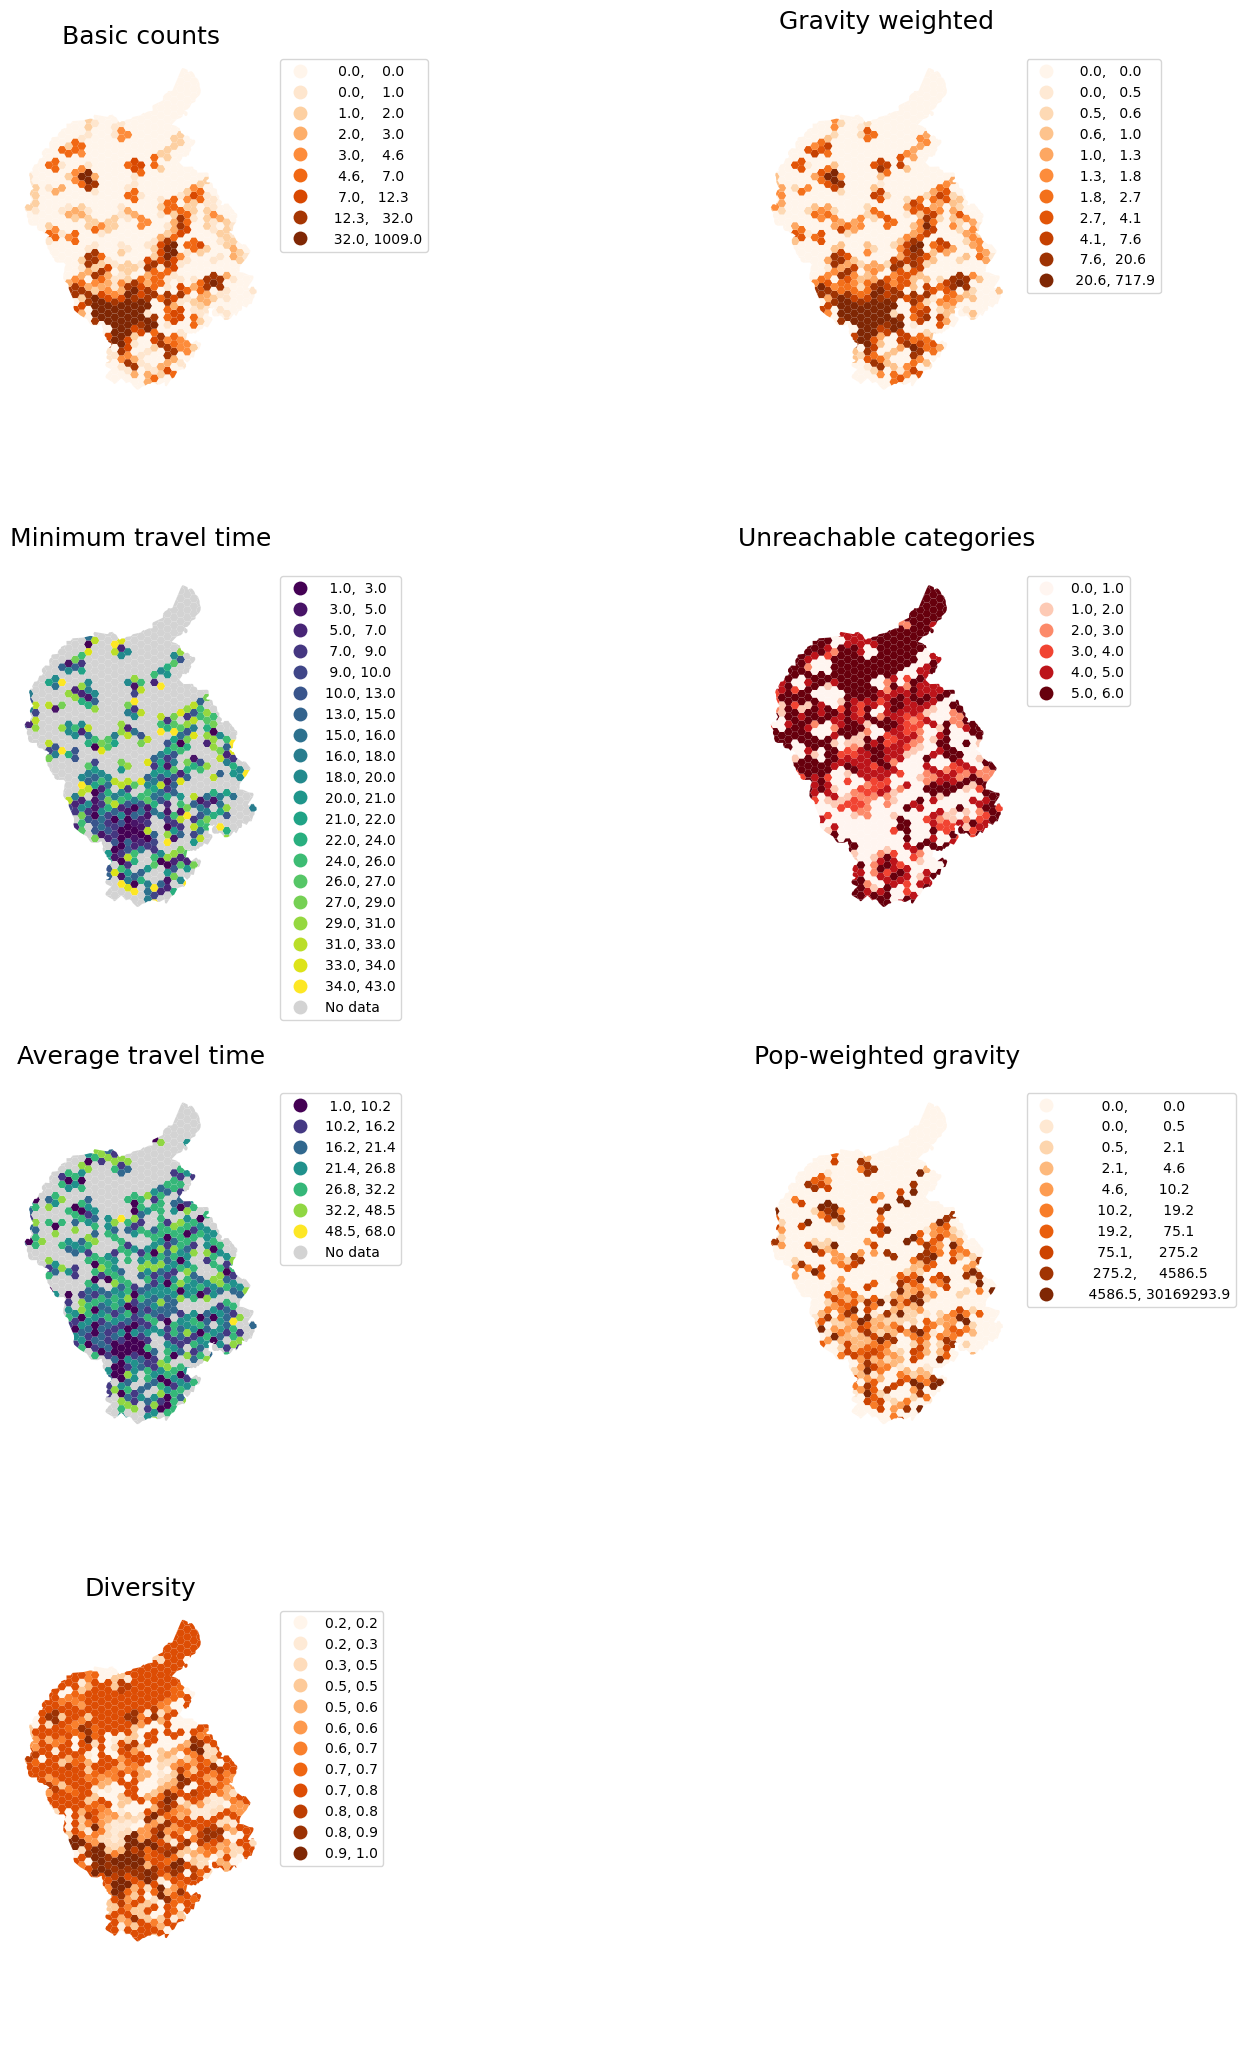

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(18, 26))
gs = fig.add_gridspec(
    nrows=8, ncols=2,
    height_ratios=[12, 1, 12, 1, 12, 1, 12, 1],
    hspace=0.35, wspace=0.15
)

plots = [
    (no_gravity, "gravity_food_and_drink", "Basic counts", "Oranges", "Quantiles", 20),
    (gravity, "gravity_food_and_drink", "Gravity weighted", "Oranges", "Quantiles", 20),
    (res, "min_tt_food_and_drink", "Minimum travel time", "viridis", "Quantiles", 20),
    (res, "n_unreachable_categories", "Unreachable categories", "Reds", "EqualInterval", 6),
    (res, "avg_tt", "Average travel time", "viridis", "NaturalBreaks", 7),
    (pop_weighed, "gravity_food_and_drink_per_1000", "Pop-weighted gravity", "Oranges", "Quantiles", 20),
    (diversity, "city_similarity", "Diversity", "Oranges", "Quantiles", 20),
]

for i, (gdf, col, ttl, cmap, scheme, k) in enumerate(plots):
    row = (i // 2) * 2
    col_idx = i % 2

    ax = fig.add_subplot(gs[row, col_idx])

    plot_hex_score(
        gdf,
        score_col=col,
        cmap=cmap,
        scheme=scheme,
        k=k,
        title=ttl,
        ax=ax,
        show=False
    )

if len(plots) % 2 == 1:
    fig.add_subplot(gs[6, 1]).axis("off")
    fig.add_subplot(gs[7, 1]).axis("off")

plt.tight_layout()
fig.savefig("bratislava_results.png", dpi=300, bbox_inches="tight")

d:\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\mapclassify\classifiers.py:1767: UserWarning: Not enough unique values in array to form 20 classes. Setting k to 9.
  self.bins = quantile(y, k=k)


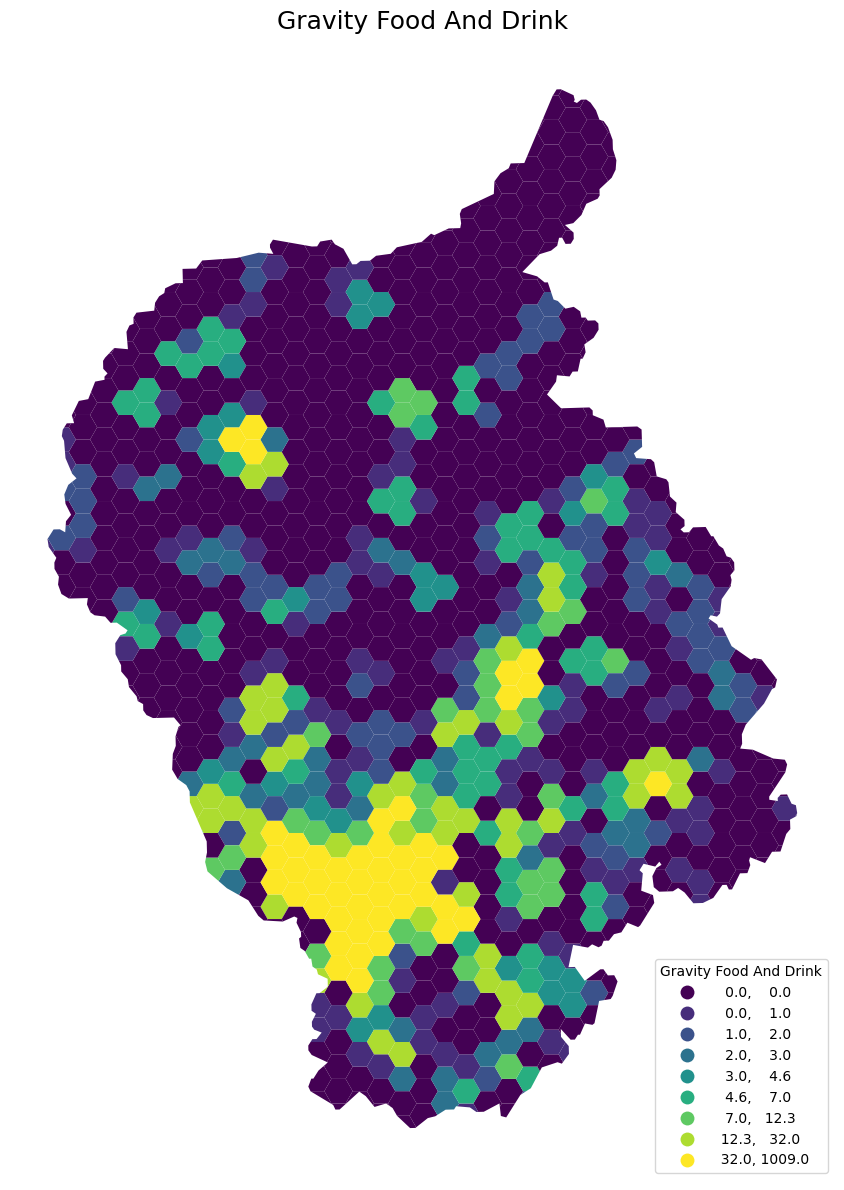

In [ ]:
# basic counts
plot_hex_score(no_gravity, score_col="gravity_food_and_drink", cmap="Oranges", k=20)

#set decay of until 50% value for threshold
plot_hex_score(gravity, score_col="gravity_food_and_drink", cmap="Oranges", k=20)
#plot_hex_score(gravity, score_col="gravity_education", k=20)
#plot_hex_score(gravity, score_col="gravity_healthcare", k=20)

#minimum travel time & travel time based measures
plot_hex_score(res, score_col="min_tt_food_and_drink", k=20)
plot_hex_score(res, score_col="n_unreachable_categories", cmap="Reds", scheme="EqualInterval", k=6)
plot_hex_score(res, score_col="avg_tt", scheme="NaturalBreaks", k=7)

#pop-weighted gravity
plot_hex_score(pop_weighed, score_col="gravity_food_and_drink_per_1000", cmap="Oranges", k=20)

#diversity
plot_hex_score(diversity, score_col="city_similarity", cmap="Oranges", k=20)